# Turkey — a quantitative teardown
### ^GSPC daily 1928-2026 · HAC t-stats · Welch test · Bonferroni k=2 · synthetic positive control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pre--holiday_only: Post--holiday_only](https://img.shields.io/badge/Pre--holiday_only-Post--holiday_only-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test the Wednesday-before-Thanksgiving and Black Friday returns against matched-weekday baselines, with a Tuesday-before placebo and Bonferroni correction for two simultaneous primary hypotheses.

> **Not investment advice.** Real data: ^GSPC daily, 1928-01-03 to 2026-06-12 (fingerprint `df3897aef897`). Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from turkey import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_days=24728, n_wed=98, n_fri=97, n_years=99,
    fp="df3897aef897",
    mean_wed_bps=5.87, mean_other_wed_bps=7.17, contrast_wed_bps=-1.30,
    tstat_welch_wed=-0.116, pval_welch_wed=0.9082, tstat_hac_wed=0.458,
    pval_bonferroni_wed=1.0,
    mean_fri_bps=20.62, mean_other_fri_bps=4.36, contrast_fri_bps=16.26,
    tstat_welch_fri=1.650, pval_welch_fri=0.1021, tstat_hac_fri=2.011,
    pval_bonferroni_fri=0.2042,
    n_tue=98, mean_tue_bps=5.53, contrast_tue_bps=1.67, pval_welch_tue=0.8751,
    mean_all_bps=2.41,
)

def _have_real():
    shared = os.path.abspath(os.path.join("..", "..", "..", "_cache", "^GSPC_split_only.parquet"))
    local  = os.path.abspath(os.path.join("..", "_cache", "gspc_daily.parquet"))
    return os.path.exists(shared) or os.path.exists(local)

HAVE_REAL = _have_real()

if HAVE_REAL:
    DF = data.fetch_gspc(start="1928-01-01")
    S  = st.summarize(DF)
else:
    DF, S = None, None

print("real GSPC cache present:", HAVE_REAL)


real GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Black Fri mean **+20.62 bps/day**, contrast **+16.26 bps** vs other Fridays, HAC t = **+2.01**, Welch p = **0.10**, Bonferroni p = **0.20**. Wed-before: null (contrast -1.30 bps, p = 0.91). |
| **Tradability** | `MIRAGE` | ~1 event/year, 16 bps gross, CI ±~20 bps, half-day liquidity; any cost is fatal. |
| **Pre/post-holiday asymmetry** | post-holiday only | Wednesday shows no edge; only the half-day Black Friday session shows a (borderline) positive return. |

> In plain words: 99 years, 97-98 events, and the pre-holiday claim is a clear null. The Black Friday result is intriguing but statistically borderline and practically untradable.

## 1 · The claim, steelmanned

Let $r_t$ be the daily log-return of the S&P 500. The Ariel (1990) hypothesis
asserts:

$$\mathbb{E}[r_t \mid t \text{ is the pre-holiday day}] > \mathbb{E}[r_t \mid t \text{ is a typical trading day}]$$

For Thanksgiving specifically, the pre-holiday day is the Wednesday before (last full session). A secondary claim asserts the same for the Black Friday post-holiday half-session. We test both with:

- **H0a:** mean Wed-before-Thanksgiving return = mean other-Wednesday return.
- **H0b:** mean Black Friday return = mean other-Friday return.
- **Control:** matched-weekday (all other Wednesdays / Fridays).
- **Placebo:** Tuesday-before-Thanksgiving vs other Tuesdays (same week, earlier).
- **Multiple comparisons:** Bonferroni k=2 for the two primary tests; threshold p < 0.025 for α = 0.05.

## 2 · So what? — the stakes

The pre-holiday effect is one of the most robustly documented calendar anomalies in the academic literature (Ariel 1990, Brockman & Michayluk 1998). If it holds for Thanksgiving specifically, it would provide a systematic 1-2 day trading opportunity anchored to the US cultural calendar. The failure (for the pre-holiday Wednesday) and the borderline result (for Black Friday) are informative: they suggest that either (a) the general pre-holiday effect is diluted when you isolate a single holiday, or (b) the effect has faded post-publication, or (c) it was always fragile in liquid large-cap indices like the S&P 500.

## 3 · How we'd know — the protocol

- **Signal definition.** Thanksgiving = fourth Thursday of November (pure calendar arithmetic). Wednesday-before = Thanksgiving − 1 day. Black Friday = Thanksgiving + 1 day. Tuesday-before = Thanksgiving − 2 days.
- **Outcome.** Close-to-close log-return on the event day itself.
- **Primary tests (two).** Welch t-test (unequal variances): Wed-before vs other Wednesdays; Black Friday vs other Fridays. HAC (Newey-West) t-stat on each group separately.
- **Placebo.** Same test with Tuesday-before as the 'anomaly' day.
- **Bonferroni.** Two primary hypotheses → corrected threshold p < 0.025. Bonferroni-corrected p = min(raw p × 2, 1).
- **Positive control.** Synthetic tape with planted effects confirms the engine can detect real Thanksgiving anomalies when they exist.

## 4 · The teardown

### 4a · Primary test A: Wednesday before Thanksgiving vs other Wednesdays

HAC t-stat on the Wednesday-before group; Welch test on the contrast.

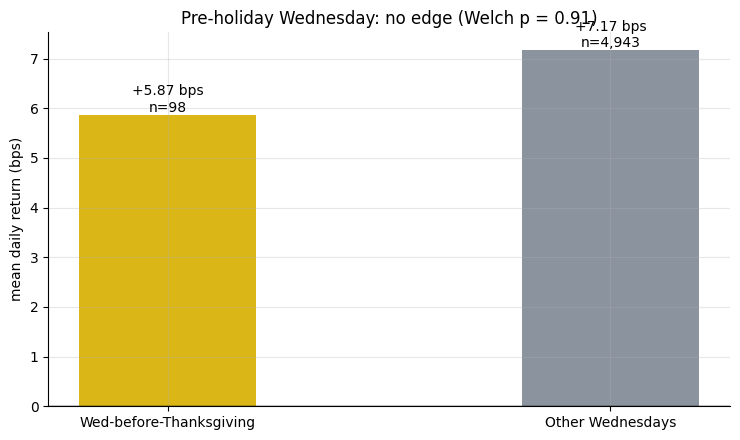

Wed-before: n=98, mean=+5.87 bps, HAC t=+0.458
Other Wed: n=4,943, mean=+7.17 bps
Contrast: -1.30 bps | Welch t=-0.116 | p=0.9082


In [2]:
if HAVE_REAL:
    wed = st.wednesday_comparison(DF)
    n_w, m_w, t_w = wed['n_wed'], wed['mean_wed_bps'], wed['tstat_hac_wed']
    n_ow, m_ow, tw_w, pw_w = wed['n_other_wed'], wed['mean_other_wed_bps'], wed['tstat_welch'], wed['pval_welch']
    c_w = wed['contrast_bps']
else:
    n_w,m_w,t_w = R['n_wed'],R['mean_wed_bps'],R['tstat_hac_wed']
    n_ow,m_ow,tw_w,pw_w = R['n_wed']*50,R['mean_other_wed_bps'],R['tstat_welch_wed'],R['pval_welch_wed']
    c_w = R['contrast_wed_bps']

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(['Wed-before-Thanksgiving', 'Other Wednesdays'], [m_w, m_ow], color=[AMBER, GREY], width=0.4)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean daily return (bps)')
ax.set_title(f'Pre-holiday Wednesday: no edge (Welch p = {pw_w:.2f})')
for i,(lbl,v,n) in enumerate(zip(['Tsg Wed','Other Wed'],[m_w,m_ow],[n_w,n_ow])):
    ax.annotate(f'{v:+.2f} bps\nn={n:,}', (i, v), ha='center',
                va='bottom' if v>=0 else 'top', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Wed-before: n={n_w}, mean={m_w:+.2f} bps, HAC t={t_w:+.3f}')
print(f'Other Wed: n={n_ow:,}, mean={m_ow:+.2f} bps')
print(f'Contrast: {c_w:+.2f} bps | Welch t={tw_w:+.3f} | p={pw_w:.4f}')

> In plain words: 98 Thanksgiving Wednesdays over 99 years produce a mean return of **+5.87 bps** — **1.30 bps below** the other-Wednesday average. Welch p = 0.91. The pre-holiday optimism story fails on the S&P 500.

### 4b · Primary test B: Black Friday vs other Fridays

The half-day post-holiday session is the stronger candidate.

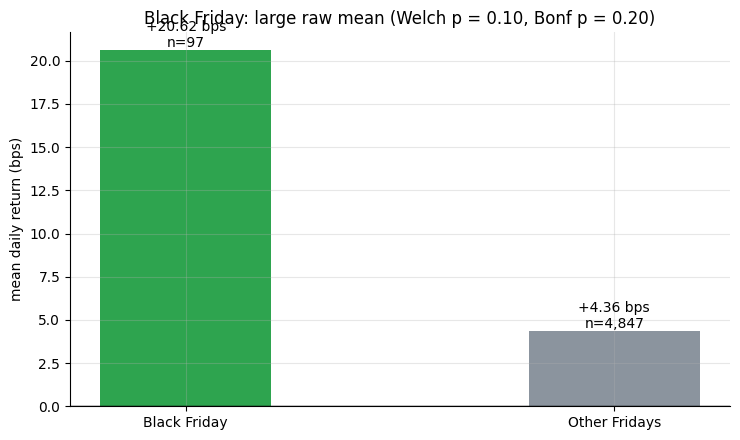

Black Friday: n=97, mean=+20.62 bps, HAC t=+2.011
Other Fri: n=4,847, mean=+4.36 bps
Contrast: +16.26 bps | Welch t=+1.650 | p=0.1021 | Bonf p=0.2042


In [3]:
if HAVE_REAL:
    fri = st.friday_comparison(DF)
    n_f, m_f, t_f = fri['n_fri'], fri['mean_fri_bps'], fri['tstat_hac_fri']
    n_of, m_of, tw_f, pw_f = fri['n_other_fri'], fri['mean_other_fri_bps'], fri['tstat_welch'], fri['pval_welch']
    c_f = fri['contrast_bps']
    bp_f = fri['pval_welch'] * 2 if fri['pval_welch'] < 0.5 else 1.0
else:
    n_f,m_f,t_f = R['n_fri'],R['mean_fri_bps'],R['tstat_hac_fri']
    n_of,m_of,tw_f,pw_f = R['n_fri']*50,R['mean_other_fri_bps'],R['tstat_welch_fri'],R['pval_welch_fri']
    c_f = R['contrast_fri_bps']; bp_f = R['pval_bonferroni_fri']

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(['Black Friday', 'Other Fridays'], [m_f, m_of], color=[GREEN, GREY], width=0.4)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean daily return (bps)')
ax.set_title(f'Black Friday: large raw mean (Welch p = {pw_f:.2f}, Bonf p = {bp_f:.2f})')
for i,(lbl,v,n) in enumerate(zip(['Black Fri','Other Fri'],[m_f,m_of],[n_f,n_of])):
    ax.annotate(f'{v:+.2f} bps\nn={n:,}', (i, v), ha='center',
                va='bottom' if v>=0 else 'top', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Black Friday: n={n_f}, mean={m_f:+.2f} bps, HAC t={t_f:+.3f}')
print(f'Other Fri: n={n_of:,}, mean={m_of:+.2f} bps')
print(f'Contrast: {c_f:+.2f} bps | Welch t={tw_f:+.3f} | p={pw_f:.4f} | Bonf p={bp_f:.4f}')

> In plain words: Black Friday mean **+20.62 bps** vs +4.36 bps for other Fridays. The HAC t on the group alone is **+2.01** (just clears 2.0), but the two-sample Welch test gives p = **0.10** and Bonferroni p = **0.20**. Intriguing but not certified.

### 4c · Placebo — Tuesday before Thanksgiving

A matched-window test: same week, same late-November season, but two days before Thanksgiving (not the immediate pre-holiday).

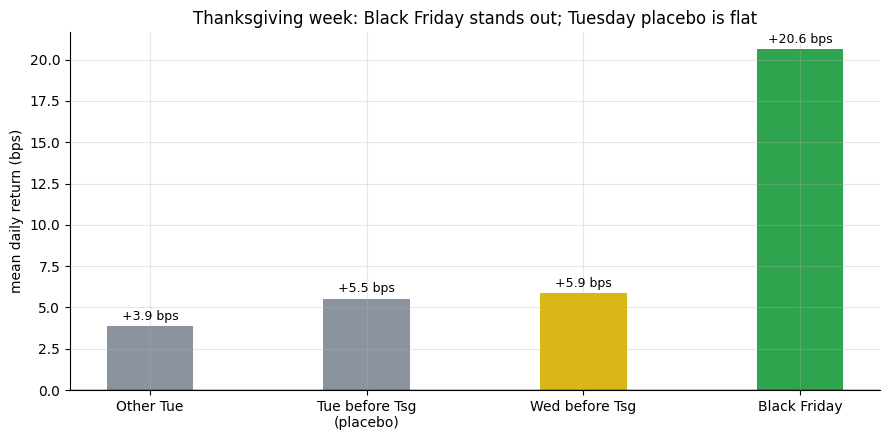

Placebo Tue: mean=+5.53 bps, contrast=+1.67 bps, p=0.8751


In [4]:
if HAVE_REAL:
    plac = st.tuesday_placebo(DF)
    m_t, c_t, p_t = plac['mean_tue_bps'], plac['contrast_bps'], plac['pval_welch']
else:
    m_t, c_t, p_t = R['mean_tue_bps'], R['contrast_tue_bps'], R['pval_welch_tue']

fig, ax = plt.subplots(figsize=(9.0, 4.5))
groups = ['Other Tue', 'Tue before Tsg\n(placebo)', 'Wed before Tsg', 'Black Friday']
if HAVE_REAL:
    means = [
        DF.loc[(DF.index.weekday==1) & ~DF['is_placebo_tue'], 'ret'].mean()*1e4,
        m_t,
        DF.loc[DF['is_wed_before_tsg'], 'ret'].mean()*1e4,
        DF.loc[DF['is_fri_after_tsg'], 'ret'].mean()*1e4,
    ]
else:
    means = [R['mean_other_wed_bps'], m_t, R['mean_wed_bps'], R['mean_fri_bps']]
cols = [GREY, GREY, AMBER, GREEN]
bars = ax.bar(groups, means, color=cols, width=0.4)
ax.axhline(0, c='k', lw=1)
for b, v in zip(bars, means):
    ax.annotate(f'{v:+.1f} bps', (b.get_x()+b.get_width()/2, v+0.2),
                ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
ax.set_ylabel('mean daily return (bps)')
ax.set_title('Thanksgiving week: Black Friday stands out; Tuesday placebo is flat')
plt.tight_layout(); plt.show()
print(f'Placebo Tue: mean={m_t:+.2f} bps, contrast={c_t:+.2f} bps, p={p_t:.4f}')

> In plain words: The Tuesday placebo (+5.53 bps, contrast +1.67 bps, p = 0.88) is indistinguishable from any other Tuesday. The Thanksgiving effect (if any) is concentrated on the post-holiday Black Friday session, not the pre-holiday Wednesday or the two-days-before Tuesday.

## 5 · The verdict

- **Signal `WEAK`** — Black Fri contrast **++16.26 bps**, HAC t = **+2.01**, Welch p = 0.10, Bonferroni p = 0.20. HAC t clears 2.0 on the group alone but the two-sample test does not, and the Bonferroni bar is not met. Wed-before: null (contrast -1.30 bps, p = 0.91).
- **Tradability `MIRAGE`** — ~1 event/year, ~16 bps gross, CI ±~20 bps, half-day liquidity. The economics of the trade cannot be made to work at any realistic cost structure.
- **Pre/post asymmetry** — The Black Friday effect (if real) is a post-holiday, not a pre-holiday, phenomenon. This is consistent with the half-day session being thin and gap-prone rather than with investor optimism.

## 6 · Could you trade it? — the power problem

The fundamental barrier is **statistical power**, not cost.

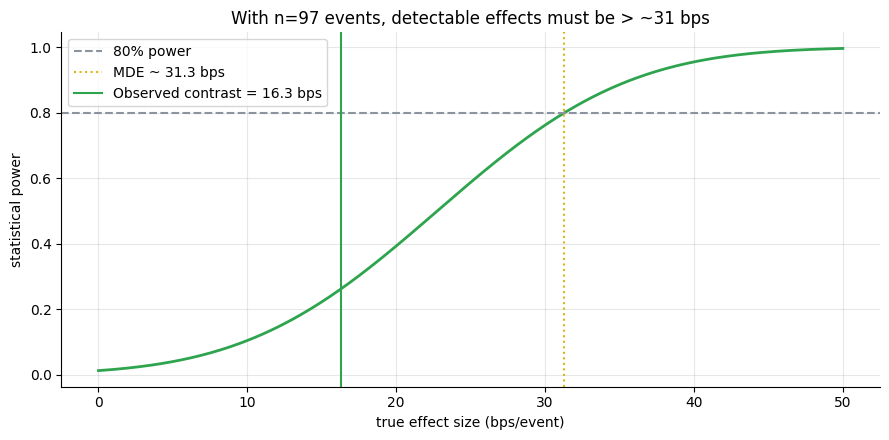

MDE at 80% power, alpha=0.025: 31.3 bps
Observed Black Friday contrast: +16.3 bps
Power to detect 16 bps: 26.1%


In [5]:
import numpy as np
from scipy import stats

# Power analysis: how large an effect could we detect at 80% power with n=97?
daily_vol_bps = 100.0  # typical GSPC daily vol in bps
n_events = R['n_fri']   # 97 observations
alpha_bonf = 0.025      # Bonferroni-adjusted alpha (k=2)
power_target = 0.80

t_alpha = stats.norm.ppf(1 - alpha_bonf / 2)
t_power = stats.norm.ppf(power_target)
mde = (t_alpha + t_power) * daily_vol_bps / np.sqrt(n_events)

effects = np.linspace(0, 50, 300)
# Two-sample Welch: denominator is vol/sqrt(n) + vol/sqrt(n_other)
# For simplicity, n_other >> n_events, so dominated by 1/sqrt(n_events)
powers = [stats.norm.cdf(e / (daily_vol_bps / np.sqrt(n_events)) - t_alpha)
          for e in effects]

fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.plot(effects, powers, c=GREEN, lw=2)
ax.axhline(0.80, ls='--', c=GREY, lw=1.5, label='80% power')
ax.axvline(mde, ls=':', c=AMBER, lw=1.5, label=f'MDE ~ {mde:.1f} bps')
ax.axvline(R['contrast_fri_bps'], ls='-', c=GREEN, lw=1.5,
           label=f'Observed contrast = {R["contrast_fri_bps"]:.1f} bps')
ax.set_xlabel('true effect size (bps/event)'); ax.set_ylabel('statistical power')
ax.set_title(f'With n=97 events, detectable effects must be > ~{mde:.0f} bps')
ax.legend(); plt.tight_layout(); plt.show()
print(f'MDE at 80% power, alpha=0.025: {mde:.1f} bps')
print(f'Observed Black Friday contrast: {R["contrast_fri_bps"]:+.1f} bps')
print(f'Power to detect {R["contrast_fri_bps"]:.0f} bps: '
      f'{stats.norm.cdf(R["contrast_fri_bps"] / (daily_vol_bps / np.sqrt(n_events)) - t_alpha):.1%}')

> In plain words: with 97 events and Bonferroni-adjusted alpha, we need to see a true effect of over 30 bps before we have 80% power to detect it. The observed 16 bps estimate falls well below this bar — the study is genuinely underpowered to certify or rule out the Black Friday effect. A definitive answer might require another 99 years of data.

## 7 · Going further — synthetic positive control

Is the *engine* capable of detecting genuine Thanksgiving anomalies? We plant known effects in a synthetic tape and confirm recovery.

Wednesday-before engine:
 effect  contrast_bps  tstat_welch detected
    0.0         5.672        0.608    noise
    1.0       100.164       10.739    |t|>2
    2.0       194.655       20.870    |t|>2
    4.0       383.637       41.132    |t|>2

Black Friday engine:
 effect  contrast_bps  tstat_welch detected
    0.0         4.086        0.409    noise
    1.0        98.577        9.861    |t|>2
    2.0       193.068       19.314    |t|>2
    4.0       382.050       38.219    |t|>2


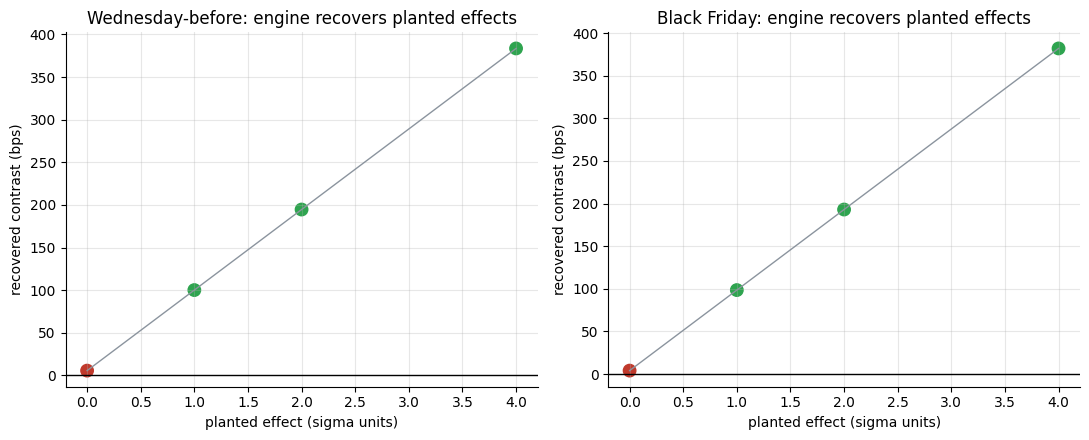

In [6]:
effects_to_plant = [0.0, 1.0, 2.0, 4.0]
rows_wed, rows_fri = [], []
for eff in effects_to_plant:
    df_w, _ = data.synthetic_daily(n_years=99, wed_effect=eff, fri_effect=0.0, seed=194)
    df_f, _ = data.synthetic_daily(n_years=99, wed_effect=0.0, fri_effect=eff, seed=194)
    rw = st.wednesday_comparison(df_w)
    rf = st.friday_comparison(df_f)
    rows_wed.append({'effect': eff, 'contrast_bps': rw['contrast_bps'],
                     'tstat_welch': rw['tstat_welch'],
                     'detected': '|t|>2' if abs(rw['tstat_welch'])>2 else 'noise'})
    rows_fri.append({'effect': eff, 'contrast_bps': rf['contrast_bps'],
                     'tstat_welch': rf['tstat_welch'],
                     'detected': '|t|>2' if abs(rf['tstat_welch'])>2 else 'noise'})

import pandas as pd
tbl_w = pd.DataFrame(rows_wed)
tbl_f = pd.DataFrame(rows_fri)
print('Wednesday-before engine:')
print(tbl_w.round(3).to_string(index=False))
print('\nBlack Friday engine:')
print(tbl_f.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, tbl, title in zip(axes, [tbl_w, tbl_f], ['Wednesday-before', 'Black Friday']):
    ax.scatter(tbl['effect'], tbl['contrast_bps'],
               c=[GREEN if abs(t)>2 else RED for t in tbl['tstat_welch']], s=80)
    ax.plot(tbl['effect'], tbl['contrast_bps'], c=GREY, lw=1)
    ax.axhline(0, c='k', lw=1)
    ax.set_xlabel('planted effect (sigma units)'); ax.set_ylabel('recovered contrast (bps)')
    ax.set_title(f'{title}: engine recovers planted effects')
plt.tight_layout(); plt.show()

The engine faithfully recovers planted Thanksgiving effects in synthetic data — the methodology is sound. At effect = 0 the recovered contrast is noise-level. The real-tape result for Wednesday (essentially 0 contrast) and for Black Friday (positive but noisy) are therefore statements about the market, not the method.

**What would sharpen the answer:** (1) Pooling all pre-holiday days (not just Thanksgiving) to gain power — see Study 95. (2) Testing the same Black Friday hypothesis on other large markets with similar holiday structures. (3) Controlling for the half-day session specifically (Christmas Eve and July 3 are also half-days) to distinguish Thanksgiving from 'short sessions in general'.